In [6]:
import sys, os
sys.path.append(os.path.abspath(".."))
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from preprocessing.preprocessing_utils import preprocess_for_tree

In [ ]:
# EVALUATION METRICS

def d_squared_poisson(y_true, y_pred, w):
    """Calculates D^2  and prints the Model Deviance and Null Deviance explicitly."""
    #  Deviance of the model
    dev_model = manual_mean_poisson_deviance(y_true, y_pred, sample_weight=w)
    
    # Intercept only
    mu = np.average(y_true, weights=w)
    y_null = np.full_like(y_true, mu)
    dev_null = manual_mean_poisson_deviance(y_true, y_null, sample_weight=w)
    
    # D^2
    d2 = 1 - (dev_model / dev_null)
    
    print(f"D^2 Calculation")
    print(f"Null Deviance (Baseline): {dev_null:.5f}")
    print(f"Model Deviance:           {dev_model:.5f}")
    print(f"D^2 Score:                {d2:.2%}")
    print(f"-----------------------")
    
    return d2

def manual_mean_poisson_deviance(y_true, y_pred, sample_weight=None):
    if sample_weight is None:
        sample_weight = np.ones_like(y_true)
    
    y_pred = np.clip(y_pred, 1e-10, None) 
    
    # Deviance formula, first term in formula 
    term1 = np.zeros_like(y_true)
    mask = y_true > 0
    term1[mask] = y_true[mask] * np.log(y_true[mask] / y_pred[mask])
    
    # second term of formula 
    term2 = -(y_true - y_pred)
    
    deviance = 2 * sample_weight * (term1 + term2)
    return np.sum(deviance) / np.sum(sample_weight)

def manual_kfold_split(n_samples, n_splits=5, shuffle=True, random_state=None):
    indices = np.arange(n_samples)
    if shuffle:
        if random_state is not None:
            np.random.seed(random_state)
        np.random.shuffle(indices)
    
    fold_sizes = np.full(n_splits, n_samples // n_splits, dtype=int)
    fold_sizes[:n_samples % n_splits] += 1
    
    current = 0
    for fold_size in fold_sizes:
        start, stop = current, current + fold_size
        val_idx = indices[start:stop]
        train_idx = np.concatenate([indices[:start], indices[stop:]])
        yield train_idx, val_idx
        current = stop
        
def plot_lorenz_curve(y_true, y_pred, w, title="Lorenz Curve"):
    """Gini coefficient visualization,  prints AUC and Gini values."""
    # Sort by predicted risk
    data = pd.DataFrame({'True': y_true, 'Pred': y_pred, 'Weight': w})
    data = data.sort_values('Pred')
    
    # Cumulative distributions
    data['CumExposure'] = data['Weight'].cumsum() / data['Weight'].sum()
    data['CumClaims'] = (data['True'] * data['Weight']).cumsum() / (data['True'] * data['Weight']).sum()
    
    # Gini Calculation
    auc = np.trapz(data['CumClaims'], data['CumExposure'])
    gini = 1 - 2 * auc 
    
    
    print(f"Gini Calculation")
    print(f"AUC: {auc:.5f}")
    print(f"Gini :{gini:.5f}")
    print(f"---------------")
    
   
    plt.figure(figsize=(6, 6))
    plt.plot(data['CumExposure'], data['CumClaims'], label=f'Model (Gini: {gini:.3f})', linewidth=2)
    plt.plot([0, 1], [0, 1], 'k--', label='Random (Gini: 0.0)')
    plt.xlabel('Cumulative Exposure (sorted by Pred Risk)')
    plt.ylabel('Cumulative Actual Claims')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return gini

def plot_calibration(y_true, y_pred, w, n_bins=10, title="Calibration Plot"):
    """
    Splits the data into risk bins (deciles) and compares Average Predicted Risk vs Average Actual Risk.
    Uses ranking to handle 'clumpy' predictions (ties) from Decision Trees, forcing exactly n_bins.
    """
    data = pd.DataFrame({'True': y_true, 'Pred': y_pred, 'Weight': w})
    
    data['Rank'] = data['Pred'].rank(method='first')
    data['Bin'] = pd.qcut(data['Rank'], n_bins)-
        
    # Calculate Weighted Averages for each bin
    grouped = data.groupby('Bin', observed=False).apply(
        lambda x: pd.Series({
            'AvgPred': np.average(x['Pred'], weights=x['Weight']),
            'AvgTrue': np.average(x['True'], weights=x['Weight']),
            'Exposure': x['Weight'].sum(),
            'Count': len(x)
        })
    )
    
    print(f"\n--- {title} Data ({n_bins} Bins) ---")
    
    print_df = grouped.copy()
    print_df['Diff'] = print_df['AvgPred'] - print_df['AvgTrue']
    print_df['Error %'] = (print_df['Diff'] / print_df['AvgTrue']) * 100
    
    print(print_df[['AvgPred', 'AvgTrue', 'Diff', 'Exposure']].to_string(float_format="%.4f"))
    print("------------------------------------------------\n")
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(grouped))
    width = 0.35
    
    ax1.bar(x - width/2, grouped['AvgPred'], width, label='Predicted Rate', alpha=0.8, color='teal')
    ax1.bar(x + width/2, grouped['AvgTrue'], width, label='Actual Rate', alpha=0.7, color='slategrey')
    
    ax1.set_xlabel('Risk Groups (Low -> High)')
    ax1.set_ylabel('Claim Rate')
    ax1.set_title(title)
    ax1.set_xticks(x)
    ax1.set_xticklabels([f"{i+1}" for i in x])
    ax1.legend(loc='upper left')
    
    ax2 = ax1.twinx()
    ax2.plot(x, grouped['Exposure'], color='red', linestyle='--', marker='o', label='Exposure Vol', alpha=0.3)
    ax2.set_ylabel('Total Exposure (Years)')
    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_feature_importance(model, feature_names, title="Feature Importance"):
    """Visualizes and prints which features are most important for DT. """
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]
    
    print(f"\n--- {title} Scores ---")
    print(f"{'Rank':<5} {'Feature':<20} {'Importance':<10}")
    print("-" * 40)
    
    # Print top 15 features or all if fewer
    top_n = min(15, len(feature_names))
    for i in range(top_n):
        idx = indices[i]
        print(f"{i+1:<5} {feature_names[idx]:<20} {importances[idx]:.5f}")
    print("-------------------------------\n")
    

    plt.figure(figsize=(10, 6))
    plt.title(title)
    plt.bar(range(len(importances)), importances[indices], align="center")
    plt.xticks(range(len(importances)), [feature_names[i] for i in indices], rotation=45, ha='right')
    plt.xlabel("Feature")
    plt.ylabel("Importance Score")
    plt.tight_layout()
    plt.show()

In [8]:
class Node:
    def __init__(self, depth, predicted_value, deviance, weight_sum):
        self.depth = depth
        self.predicted_value = predicted_value
        self.deviance = deviance 
        self.weight_sum = weight_sum
        
        self.feature_index = None
        self.threshold = None
        self.left = None
        self.right = None
        self.is_leaf = True
        

        self.effective_alpha = np.inf

class PoissonDecisionTreeScratch:
    def __init__(self, max_depth=5, min_leaf_weight=1.0, ccp_alpha=0.0):
        self.max_depth = max_depth
        self.min_leaf_weight = min_leaf_weight
        self.ccp_alpha = ccp_alpha
        self.root = None
        self.feature_importances_ = None 

    def fit(self, X, y, sample_weight=None):
        if sample_weight is None:
            sample_weight = np.ones(len(y))
        
        
        total_samples_w = np.sum(sample_weight)

        n_features = X.shape[1]
        self.feature_importances_ = np.zeros(n_features)

        self.root = self._grow_tree(X, y, sample_weight, depth=0)

        
        if self.ccp_alpha > 0.0:
            self._prune_tree(self.root, self.ccp_alpha, total_samples_w)
            
        total_importance = np.sum(self.feature_importances_)
        if total_importance > 0:
            self.feature_importances_ /= total_importance

    def _calc_deviance(self, y, w, pred):
        if pred <= 0: return 0.0 
        
        mask = y > 0
        y_log_y = np.zeros_like(y)
        y_log_y[mask] = y[mask] * np.log(y[mask])
        
        y_log_pred = y * np.log(pred)

        return 2 * np.sum(w * (y_log_y - y_log_pred))

    def _grow_tree(self, X, y, w, depth):
        total_w = np.sum(w)
        prediction = np.sum(w * y) / total_w if total_w > 0 else 0.0
        node_deviance = self._calc_deviance(y, w, prediction)
        
        node = Node(depth, prediction, node_deviance, total_w)
        
        if depth >= self.max_depth or total_w < 2 * self.min_leaf_weight:
            return node
        if len(np.unique(y)) == 1:
            return node

        best_feat, best_thresh = self._find_best_split(X, y, w)
        
        if best_feat is None:
            return node
        
        left_mask = X[:, best_feat] <= best_thresh
        right_mask = ~left_mask
        
        node.feature_index = best_feat
        node.threshold = best_thresh
        node.is_leaf = False
        
        node.left = self._grow_tree(X[left_mask], y[left_mask], w[left_mask], depth + 1)
        node.right = self._grow_tree(X[right_mask], y[right_mask], w[right_mask], depth + 1)
        
        deviance_reduction = node.deviance - (node.left.deviance + node.right.deviance)
        
        if deviance_reduction > 0:
            self.feature_importances_[best_feat] += deviance_reduction

        return node

    def _find_best_split(self, X, y, w):
        n_samples, n_features = X.shape
        
        
        total_S = np.sum(w * y)
        total_W = np.sum(w)
        eps = 1e-10
        
        parent_mean = total_S / (total_W + eps)
        parent_score = total_S * np.log(parent_mean + eps)
        
        best_gain = 0.0 
        best_feat = None
        best_thresh = None
        
        for feat_idx in range(n_features):
            idxs = np.argsort(X[:, feat_idx])
            X_sort = X[idxs, feat_idx]
            y_sort = y[idxs]
            w_sort = w[idxs]
            
            lhs_W = np.cumsum(w_sort)
            lhs_S = np.cumsum(w_sort * y_sort)
            rhs_W = total_W - lhs_W
            rhs_S = total_S - lhs_S
            
            valid_mask = (lhs_W >= self.min_leaf_weight) & (rhs_W >= self.min_leaf_weight)
            unique_val_mask = np.zeros(len(X_sort), dtype=bool)
            unique_val_mask[:-1] = X_sort[:-1] != X_sort[1:]
            valid_mask = valid_mask & unique_val_mask
            
            if not np.any(valid_mask): continue
                
            eps = 1e-10
            mean_L = lhs_S[valid_mask] / (lhs_W[valid_mask] + eps)
            score_L = lhs_S[valid_mask] * np.log(mean_L + eps)
            mean_R = rhs_S[valid_mask] / (rhs_W[valid_mask] + eps)
            score_R = rhs_S[valid_mask] * np.log(mean_R + eps)
            
            gains = score_L + score_R
            
            improvement = gains - parent_score
            
            if len(improvement) > 0:
                max_idx = np.argmax(improvement)
                
                
                if improvement[max_idx] > best_gain + 1e-7:
                    best_gain = improvement[max_idx]
                    best_feat = feat_idx
                    best_thresh = X_sort[np.where(valid_mask)[0][max_idx]]
                    
        return best_feat, best_thresh

    def cost_complexity_pruning_path(self, X, y, w):
        if self.root is None: self.fit(X, y, w)
        total_w = np.sum(w)
        self._compute_tree_stats(self.root, total_sample_weight=total_w)
        
        alphas = []
        self._collect_alphas(self.root, alphas)
        alphas = sorted(list(set(alphas)))
        alphas = [a for a in alphas if a >= 0]
        if 0.0 not in alphas: alphas.insert(0, 0.0)
        class Path:
            def __init__(self, ccp_alphas):
                self.ccp_alphas = np.array(ccp_alphas)
        return Path(alphas)

    def _compute_tree_stats(self, node, total_sample_weight=1.0):
        if node.is_leaf:
            node.subtree_deviance = node.deviance
            node.n_leaves = 1
            node.effective_alpha = np.inf
        else:
            
            left_R, left_L = self._compute_tree_stats(node.left, total_sample_weight)
            right_R, right_L = self._compute_tree_stats(node.right, total_sample_weight)
            
            node.subtree_deviance = left_R + right_R
            node.n_leaves = left_L + right_L
            
            if node.n_leaves > 1:
                raw_alpha = (node.deviance - node.subtree_deviance) / (node.n_leaves - 1)
                node.effective_alpha = raw_alpha / total_sample_weight
            else:
                node.effective_alpha = np.inf
                
        return node.subtree_deviance, node.n_leaves

    def _collect_alphas(self, node, alphas):
        if not node.is_leaf:
            alphas.append(node.effective_alpha)
            self._collect_alphas(node.left, alphas)
            self._collect_alphas(node.right, alphas)

    def _prune_tree(self, node, alpha, total_w):
        if node.is_leaf: return
        

        self._compute_tree_stats(node, total_sample_weight=total_w)
        
        if node.effective_alpha <= alpha:
            node.is_leaf = True
            node.left = None
            node.right = None
        else:
            self._prune_tree(node.left, alpha, total_w)
            self._prune_tree(node.right, alpha, total_w)

    def predict(self, X):
        return np.array([self._traverse(x, self.root) for x in X])

    def _traverse(self, x, node):
        if node.is_leaf: return node.predicted_value
        if x[node.feature_index] <= node.threshold:
            return self._traverse(x, node.left)
        else:
            return self._traverse(x, node.right)

In [9]:

# DATA LOADING AND PREPROCESSING

train = pd.read_csv("../data/claims_train.csv")
test  = pd.read_csv("../data/claims_test.csv")

X_tr, y_tr_rate, w_tr = preprocess_for_tree(train)
X_te, y_te_rate, w_te = preprocess_for_tree(test)
feature_names = list(X_tr.columns) 
print(f"Feature names extracted: {feature_names}")

# Convert to numpy for sklearn, efficiency
X_train = X_tr.values.astype(np.float32)
y_train = y_tr_rate.values.astype(np.float32)
w_train = w_tr.values.astype(np.float32)

X_test = X_te.values.astype(np.float32)
y_test = y_te_rate.values.astype(np.float32)
w_test = w_te.values.astype(np.float32)

Feature names extracted: ['VehPower', 'VehAge', 'DrivAge', 'BonusMalus', 'Density', 'Area_Int', 'VehBrand_B10', 'VehBrand_B11', 'VehBrand_B12', 'VehBrand_B13', 'VehBrand_B14', 'VehBrand_B2', 'VehBrand_B3', 'VehBrand_B4', 'VehBrand_B5', 'VehBrand_B6', 'VehGas_Regular', 'Region_R21', 'Region_R22', 'Region_R23', 'Region_R24', 'Region_R25', 'Region_R26', 'Region_R31', 'Region_R41', 'Region_R42', 'Region_R43', 'Region_R52', 'Region_R53', 'Region_R54', 'Region_R72', 'Region_R73', 'Region_R74', 'Region_R82', 'Region_R83', 'Region_R91', 'Region_R93', 'Region_R94']


In [10]:
# M1: DECISION TREE MANUAL
# Hyperparameter Tuning, Depth and  Min Leaf

depth_grid = [6, 7, 8, 9, 10] 
leaf_weight_grid = [10, 20, 30, 50, 100, 250]

best_params = {"depth": None, "leaf_w": None, "score": np.inf}

for d in depth_grid:
    for lw in leaf_weight_grid:
        fold_scores = []
        splitter = manual_kfold_split(len(X_train), n_splits=5, random_state=7)
        
        for train_idx, val_idx in splitter:
            X_f, y_f, w_f = X_train[train_idx], y_train[train_idx], w_train[train_idx]
            X_v, y_v, w_v = X_train[val_idx], y_train[val_idx], w_train[val_idx]
            
            dt = PoissonDecisionTreeScratch(max_depth=d, min_leaf_weight=float(lw))
            dt.fit(X_f, y_f, sample_weight=w_f)
            preds = dt.predict(X_v)
            dev = manual_mean_poisson_deviance(y_v, preds, sample_weight=w_v)
            fold_scores.append(dev)
            
        avg_dev = np.mean(fold_scores)
        print(f"Depth: {d}, Leaf W: {lw} -> Deviance: {avg_dev:.5f}")
        
        if avg_dev < best_params["score"]:
            best_params = {"depth": d, "leaf_w": lw, "score": avg_dev}

print(f"Best Params: {best_params}")

Depth: 6, Leaf W: 10 -> Deviance: 0.58276
Depth: 6, Leaf W: 20 -> Deviance: 0.58254
Depth: 6, Leaf W: 30 -> Deviance: 0.58198
Depth: 6, Leaf W: 50 -> Deviance: 0.58247
Depth: 6, Leaf W: 100 -> Deviance: 0.58096
Depth: 6, Leaf W: 250 -> Deviance: 0.58091
Depth: 7, Leaf W: 10 -> Deviance: 0.58590
Depth: 7, Leaf W: 20 -> Deviance: 0.58421
Depth: 7, Leaf W: 30 -> Deviance: 0.58342
Depth: 7, Leaf W: 50 -> Deviance: 0.58255
Depth: 7, Leaf W: 100 -> Deviance: 0.58006
Depth: 7, Leaf W: 250 -> Deviance: 0.58025
Depth: 8, Leaf W: 10 -> Deviance: 0.59897
Depth: 8, Leaf W: 20 -> Deviance: 0.59374
Depth: 8, Leaf W: 30 -> Deviance: 0.59281
Depth: 8, Leaf W: 50 -> Deviance: 0.58750
Depth: 8, Leaf W: 100 -> Deviance: 0.58282
Depth: 8, Leaf W: 250 -> Deviance: 0.58033
Depth: 9, Leaf W: 10 -> Deviance: 0.61839
Depth: 9, Leaf W: 20 -> Deviance: 0.60628
Depth: 9, Leaf W: 30 -> Deviance: 0.60215
Depth: 9, Leaf W: 50 -> Deviance: 0.59570
Depth: 9, Leaf W: 100 -> Deviance: 0.58551
Depth: 9, Leaf W: 250 -> De

In [11]:
# Cost Complexity Prunning

# build large tree to get alphas
tree_large = PoissonDecisionTreeScratch(
    max_depth=best_params["depth"],
    min_leaf_weight=float(best_params["leaf_w"])
)
tree_large.fit(X_train, y_train, sample_weight=w_train)

# Getting alphas using our manual method
path = tree_large.cost_complexity_pruning_path(X_train, y_train, w_train)
ccp_alphas = path.ccp_alphas

# Limit alphas, reasonable number for speed
if len(ccp_alphas) > 20:
    indices = np.linspace(0, len(ccp_alphas)-1, 20, dtype=int)
    ccp_alphas = ccp_alphas[indices]


best_alpha_params = {"alpha": 0.0, "score": np.inf}

# CV, find optimal Alpha
for alpha in ccp_alphas:
    fold_scores = []
    splitter = manual_kfold_split(len(X_train), n_splits=5, random_state=7)
    
    for train_idx, val_idx in splitter:
        X_f, y_f, w_f = X_train[train_idx], y_train[train_idx], w_train[train_idx]
        X_v, y_v, w_v = X_train[val_idx], y_train[val_idx], w_train[val_idx]
        
        # Init with alpha
        dt = PoissonDecisionTreeScratch(
            max_depth=best_params["depth"],
            min_leaf_weight=float(best_params["leaf_w"]),
            ccp_alpha=alpha
        )
        dt.fit(X_f, y_f, sample_weight=w_f)
        
        preds = dt.predict(X_v)
        dev = manual_mean_poisson_deviance(y_v, preds, sample_weight=w_v)
        fold_scores.append(dev)
    
    avg = np.mean(fold_scores)
    print(f"Alpha: {alpha:.6f} -> Deviance: {avg:.5f}")
    
    if avg < best_alpha_params["score"]:
        best_alpha_params = {"alpha": alpha, "score": avg}

print(f"Best Alpha: {best_alpha_params['alpha']:.6f} with CV Deviance: {best_alpha_params['score']:.5f}")

Alpha: 0.000000 -> Deviance: 0.58006
Alpha: 0.000013 -> Deviance: 0.57997
Alpha: 0.000017 -> Deviance: 0.57991
Alpha: 0.000022 -> Deviance: 0.57969
Alpha: 0.000025 -> Deviance: 0.57968
Alpha: 0.000027 -> Deviance: 0.57966
Alpha: 0.000030 -> Deviance: 0.57965
Alpha: 0.000032 -> Deviance: 0.57971
Alpha: 0.000035 -> Deviance: 0.57955
Alpha: 0.000038 -> Deviance: 0.57939
Alpha: 0.000044 -> Deviance: 0.57931
Alpha: 0.000060 -> Deviance: 0.57942
Alpha: 0.000076 -> Deviance: 0.57970
Alpha: 0.000094 -> Deviance: 0.58059
Alpha: 0.000108 -> Deviance: 0.58152
Alpha: 0.000127 -> Deviance: 0.58257
Alpha: 0.000212 -> Deviance: 0.58529
Alpha: 0.000305 -> Deviance: 0.59115
Alpha: 0.000369 -> Deviance: 0.60114
Alpha: 0.000661 -> Deviance: 0.62472
Best Alpha: 0.000044 with CV Deviance: 0.57931


D^2 Calculation
Null Deviance (Baseline): 0.63304
Model Deviance:           0.58506
D^2 Score:                7.58%
-----------------------
Gini Calculation
AUC: 0.34354
Gini :0.31292
---------------


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3492\2344837513.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  auc = np.trapz(data['CumClaims'], data['CumExposure'])


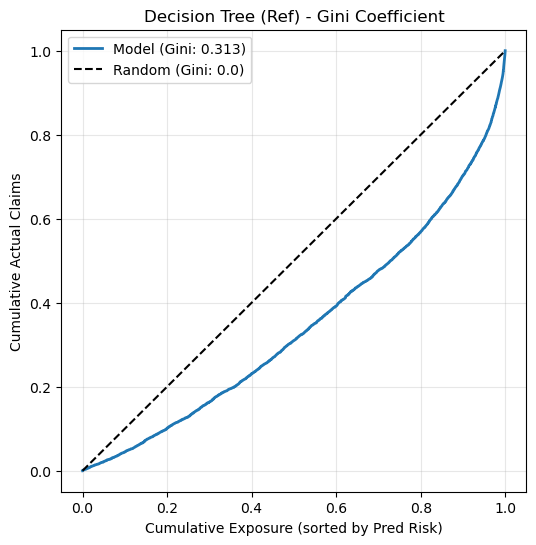


--- Calibration Plot Data (10 Bins) ---
                      AvgPred  AvgTrue    Diff  Exposure
Bin                                                     
(0.999, 13561.2]       0.0416   0.0465 -0.0049 8211.3359
(13561.2, 27121.4]     0.0591   0.0583  0.0008 8630.8037
(27121.4, 40681.6]     0.0683   0.0700 -0.0017 6175.6978
(40681.6, 54241.8]     0.0775   0.0697  0.0077 7585.0566
(54241.8, 67802.0]     0.0819   0.0846 -0.0028 9029.4766
(67802.0, 81362.2]     0.0819   0.0794  0.0024 9067.5498
(81362.2, 94922.4]     0.0887   0.0910 -0.0023 6332.0439
(94922.4, 108482.6]    0.1173   0.1146  0.0027 5636.7324
(108482.6, 122042.8]   0.1450   0.1581 -0.0131 6142.5273
(122042.8, 135603.0]   0.3619   0.3665 -0.0046 4815.6406
------------------------------------------------



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_3492\2344837513.py:110: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = data.groupby('Bin', observed=False).apply(


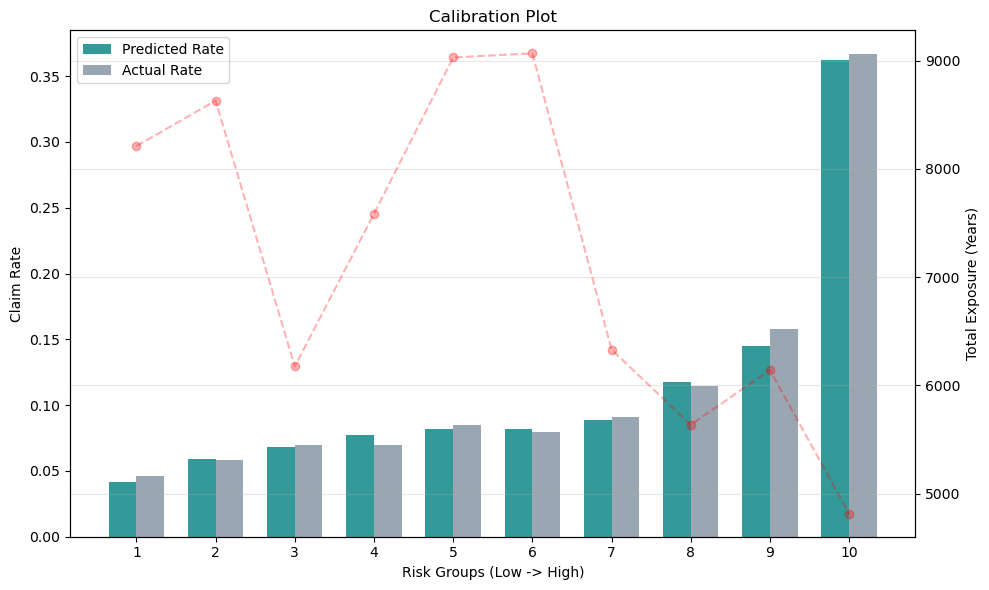


--- Feature Importance Scores ---
Rank  Feature              Importance
----------------------------------------
1     BonusMalus           0.33565
2     VehAge               0.31799
3     VehBrand_B12         0.10431
4     VehPower             0.08927
5     VehGas_Regular       0.06245
6     DrivAge              0.05979
7     Density              0.02283
8     Region_R41           0.00330
9     Region_R91           0.00238
10    VehBrand_B11         0.00114
11    VehBrand_B4          0.00049
12    Region_R93           0.00041
13    Area_Int             0.00000
14    VehBrand_B10         0.00000
15    VehBrand_B13         0.00000
-------------------------------



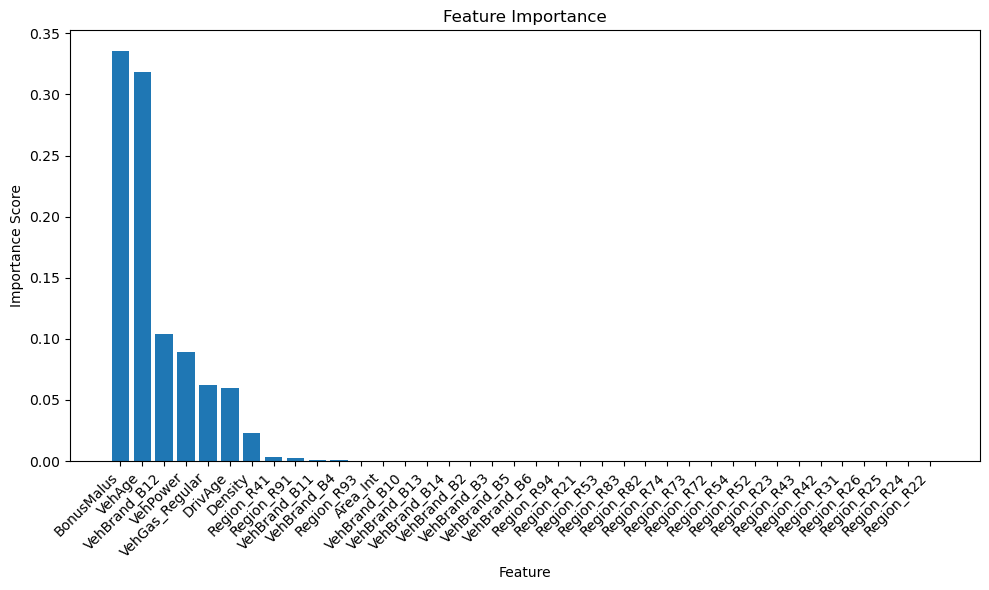

In [27]:

#  FINAL MODEL AND EVALUATION

final_model = PoissonDecisionTreeScratch(
max_depth=best_params["depth"],
    min_leaf_weight=float(best_params["leaf_w"]),
    ccp_alpha=best_alpha_params["alpha"]
)

final_model.fit(X_train, y_train, sample_weight=w_train)
test_preds = final_model.predict(X_test)

# Metrics
test_deviance = manual_mean_poisson_deviance(y_test, test_preds, sample_weight=w_test)
d2 = d_squared_poisson(y_test, test_preds, w_test)

# Gini Plot
plot_lorenz_curve(y_test, test_preds, w_test, title="Decision Tree (Ref) - Gini Coefficient")

#Calibration Plot
plot_calibration(y_test, test_preds, w_test, n_bins=10)

# Feature Importance
feature_names = list(X_tr.columns) 
plot_feature_importance(final_model, feature_names)